# DLinear — Walmart Store Sales Forecasting


Setup — attach the two utility scripts


1. **`preprocessor`** — your existing preprocessor. We reuse only its lightweight,
   contract-defining pieces (`merge_and_preprocess`, `make_masks`, `clean_target`)
   so this model sees the **exact same** split and target cleaning as your trees.
2. **`walmart_ts_common`** — shared TS infrastructure *and* the experiment
   tracker (`build_panel`, `SeriesStore`, `score_val_predictions`,
   `wmae_breakdown`, `ExperimentTracker`, `build_submission`).



In [2]:
import sys, glob, time
for p in glob.glob("/kaggle/usr/lib/*") + glob.glob("/kaggle/input/*"):
    if p not in sys.path:
        sys.path.append(p)

sys.path.append("/kaggle/input/datasets/ldavi22/prophet/")


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import walmart_ts_common as C

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_DATAPARALLEL = False        # flip on to split each batch across 2x T4
print("torch", torch.__version__, "| device:", DEVICE, "| GPUs:", torch.cuda.device_count())

torch 2.10.0+cu128 | device: cuda | GPUs: 2


## MLflow / DagsHub logging

Every trial is mirrored to **your** DagsHub-backed MLflow: params = the `cfg`, metrics = `val_wmae` plus the holiday / non-holiday split. A final `*_Best` run (in §6) logs the submission, the trained model, and the experiment log as artifacts.



In [3]:
!pip install dagshub "mlflow>=2.22.0" -q

DAGSHUB_OWNER = "nikaduri"
DAGSHUB_REPO  = "ml-store-sales-forecasting"
MLFLOW_EXPERIMENT = "DLinear_Training"

_token = None
try:
    from kaggle_secrets import UserSecretsClient
    _token = UserSecretsClient().get_secret("0142044919a46f4fd30e1c27f1b9fcb18c22472b")
except Exception:
    _token = None

C.setup_dagshub_mlflow(DAGSHUB_OWNER, DAGSHUB_REPO, token=_token)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 819.8 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 3.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 59.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 86.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=20771d0c-9f55-4711-94ac-2a9c476f7ebb&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=9604ecfdf3ced60a2edf1e501158a5b9f69aa74e84a95567f3f69ba875572c6f




Accessing as ldavi22

Initialized MLflow to track repo "nikaduri/ml-store-sales-forecasting"

Repository nikaduri/ml-store-sales-forecasting initialized!

MLflow -> https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow  (auth: oauth)


'https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow'

## 1 · Build the canonical panel (the shared contract)

`build_panel()` calls **your** `preprocessor.py`: identical **last-8-weeks**
split (`make_masks`) and identical target cleaning (`clean_target` — train region
IQR-clipped, val region kept true). WMAE uses a 5× holiday weight, matching the
preprocessor's `w_val`. Every model in the comparison is scored on these same 8
weeks, so any WMAE difference is the model, not the pipeline.

In [4]:
panel = C.build_panel()
store = C.SeriesStore(panel)
print(f"series: {len(store.series):,} | val weeks: {store.n_val} | test weeks: {len(store.test_dates)}")

series: 3,331 | val weeks: 8 | test weeks: 39


## 2 · Windowing — one global, channel-independent dataset

**Global, not per-series:** each series has only ~140 weekly points, so we slice
every series into univariate `(input_len → pred_len)` windows and pool them into
one model. Pooling learns shared seasonality/holiday structure; univariate
slicing keeps it channel-independent (series never mix within a sample).

Baked into `make_training_windows`: `pred_len = 8` (= the val horizon, so the
model trains for exactly what it's scored on); **per-series train-region
normalization** (leak-free, and per Store-Dept because store scales differ
wildly); and **no leakage / no fabricated targets** (a window is kept only if its
whole target is in the train region and originally observed; short input gaps are
interpolated on a regular weekly grid).

`input_len` is a **hyperparameter** below — bigger lookback sees more seasonality
but disqualifies short series (watch `n_fallback` move).

## 3 · Model definition

In [5]:
class MovingAvg(nn.Module):
    def __init__(self, kernel_size):
        super().__init__(); self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=0)
    def forward(self, x):
        x = x.unsqueeze(-1); pad = (self.kernel_size - 1) // 2
        front = x[:, :1, :].repeat(1, pad, 1)
        end   = x[:, -1:, :].repeat(1, self.kernel_size - 1 - pad, 1)
        x = torch.cat([front, x, end], dim=1)
        return self.avg(x.permute(0, 2, 1)).permute(0, 2, 1).squeeze(-1)

class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__(); self.moving_avg = MovingAvg(kernel_size)
    def forward(self, x):
        trend = self.moving_avg(x); return x - trend, trend

class DLinear(nn.Module):
    def __init__(self, input_len, pred_len, kernel_size=25):
        super().__init__()
        self.decomp = SeriesDecomp(kernel_size)
        self.lin_seasonal = nn.Linear(input_len, pred_len)
        self.lin_trend    = nn.Linear(input_len, pred_len)
    def forward(self, x):
        s, t = self.decomp(x); return self.lin_seasonal(s) + self.lin_trend(t)

def build_model(cfg, pred_len=None):
    return DLinear(cfg["input_len"], pred_len or cfg["pred_len"],
                   kernel_size=cfg["kernel_size"])

In [6]:
_wmeta, _vcache, _vtcache = {}, {}, {}
def get_windows_meta(L, H):
    if (L, H) not in _wmeta:
        _wmeta[(L, H)] = store.make_training_windows(L, H, return_meta=True)
    return _wmeta[(L, H)]
def get_windows(L, H):
    X, Y, *_ = get_windows_meta(L, H); return X, Y
def get_val_inputs(L):
    if L not in _vcache: _vcache[L] = store.make_val_inputs(L)
    return _vcache[L]
def get_val_targets(L, keys):
    if L not in _vtcache: _vtcache[L] = store.make_val_targets(keys)
    return _vtcache[L]

def set_seed(s):
    np.random.seed(s); torch.manual_seed(s)

def _val_loss(model, Xv_t, Yv_t, Mv_t):
    # normalized L1 on observed val weeks -> same units as the train loss,
    # so train_loss vs val_loss per epoch is a real overfitting curve
    with torch.no_grad():
        diff = (model(Xv_t) - Yv_t).abs() * Mv_t
    return float(diff.sum().item() / Mv_t.sum().clamp(min=1).item())

def train_torch(model, X, Y, lr, epochs, batch_size, val=None):
    model = model.to(DEVICE)
    if USE_DATAPARALLEL and torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(Y)),
                        batch_size=batch_size, shuffle=True)
    Xv_t = Yv_t = Mv_t = None
    if val is not None:
        Xv, Yv, Mv = val
        Xv_t, Yv_t, Mv_t = (torch.tensor(a).to(DEVICE) for a in (Xv, Yv, Mv))
    history = []
    for ep in range(epochs):
        model.train(); running, nb = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = nn.functional.l1_loss(model(xb), yb)   # MAE aligns with WMAE
            loss.backward(); opt.step()
            running += loss.item(); nb += 1
        row = {"epoch": ep, "train_loss": running / max(nb, 1)}
        if val is not None:
            model.eval(); row["val_loss"] = _val_loss(model, Xv_t, Yv_t, Mv_t)
        history.append(row)
    return model, history

def _predict(model, Xarr, bs=8192):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(Xarr), bs):
            out.append(model(torch.tensor(Xarr[i:i + bs]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out, 0) if out else np.empty((0, 0), np.float32)

TRIAL_CFGS = {}
def run_trial(cfg, tracker=None, note="", return_predictions=False):
    set_seed(cfg["seed"])
    L, H = cfg["input_len"], cfg["pred_len"]
    X, Y = get_windows(L, H)
    Xv, keys, mus, sds = get_val_inputs(L)
    Yv_norm, Mv = get_val_targets(L, keys)

    t0 = time.time()
    model, history = train_torch(build_model(cfg), X, Y, cfg["lr"], cfg["epochs"],
                                 cfg["batch_size"], val=(Xv, Yv_norm, Mv))
    secs = time.time() - t0

    # ---- validation metrics (dollars, via the shared scorer) ----
    pv = _predict(model, Xv)
    pbk = {k: pv[i] * sds[i] + mus[i] for i, k in enumerate(keys)}
    n_model = len(pbk)
    for k in store.series:
        pbk.setdefault(k, store.naive_val(k))
    _, merged = C.score_val_predictions(panel, store, pbk)
    val_m = C.regression_metrics(merged["y_true"], merged["y_pred"],
                                 merged["IsHoliday"], prefix="val_")

    # ---- training metrics (dollars, over the training windows) ----
    Xt, Yt, tmus, tsds, thol = get_windows_meta(L, H)
    pt = _predict(model, Xt)
    tr_pred = pt * tsds[:, None] + tmus[:, None]
    tr_true = Yt * tsds[:, None] + tmus[:, None]
    train_m = C.regression_metrics(tr_true, tr_pred, thol, prefix="train_")

    metrics = {
        "train_mae":  train_m["train_mae"],  "val_mae":  val_m["val_mae"],
        "train_wmae": train_m["train_wmae"], "val_wmae": val_m["val_wmae"],
        "val_rmse":   val_m["val_rmse"],     "val_r2":   val_m["val_r2"],
        "n_fallback": len(store.series) - n_model,
        "train_secs": round(secs, 1),
        "n_params":   sum(p.numel() for p in build_model(cfg).parameters()),
    }
    if tracker is not None:
        tid = tracker.log(cfg, metrics, note, history=history)
        TRIAL_CFGS[tid] = dict(cfg)
    if return_predictions:
        return metrics, merged
    return metrics

## 4 · Run the experiments
### DLinear — decomposition + linear

Trend (moving average) + seasonal (remainder), each mapped by one
`Linear(input_len → pred_len)`. Because we chose the pooled-univariate global
setup, this is the **shared-weight** DLinear by construction (the paper's
per-channel variant needs the multivariate formulation, which a ragged
3,000-series panel can't support). A few hundred parameters, so trials are almost
free — sweep `input_len` and `kernel_size` freely.

Hyperparameters worth trialing: `input_len`, `kernel_size` (trend smoothness),
`lr`, `epochs`.

In [7]:
BASE = dict(input_len=52, pred_len=8, epochs=40, lr=1e-3, batch_size=512,
            seed=42, kernel_size=25)

tracker = C.ExperimentTracker("dlinear", mlflow_experiment=MLFLOW_EXPERIMENT)
run_trial(BASE,                          tracker, note="baseline")

# -- optimization (a few hundred params -> LR is the main lever) --
run_trial({**BASE, "lr": 3e-3},          tracker, note="higher lr")
run_trial({**BASE, "lr": 3e-4},          tracker, note="lower lr")

# -- the decomposition knob: what counts as trend vs. seasonal --
run_trial({**BASE, "kernel_size": 13},   tracker, note="smaller trend kernel")
run_trial({**BASE, "kernel_size": 51},   tracker, note="smoother trend")

# -- lookback --
run_trial({**BASE, "input_len": 26},     tracker, note="short lookback")
run_trial({**BASE, "input_len": 104},    tracker, note="2-year lookback")

# -- train longer (cheap model, so free to check) --
run_trial({**BASE, "epochs": 80},        tracker, note="train longer")

[dlinear] MLflow ON -> experiment 'DLinear_Training'
🏃 View run dlinear_trial01_baseline at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/5/runs/6e2e784996f744ba8d1d7dc15f926188
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/5
[dlinear · trial 1] val_wmae=1538.08  <- new best  note='baseline'
🏃 View run dlinear_trial02_higher_lr at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/5/runs/f3461c2efb8a45369837f7bdd9f17e27
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/5
[dlinear · trial 2] val_wmae=1550.26  | best: trial 1 @ 1538.08  note='higher lr'
🏃 View run dlinear_trial03_lower_lr at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/5/runs/9b7082deeeba485583461137d2f344dc
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/5
[dlinear · trial 3] val

{'train_mae': 1616.57,
 'val_mae': 1534.88,
 'train_wmae': 1703.86,
 'val_wmae': 1522.18,
 'val_rmse': 3117.92,
 'val_r2': 0.9795,
 'n_fallback': 591,
 'train_secs': 148.2,
 'n_params': 848}

## 5 · Compare trials

`summary()` is the leaderboard (best WMAE first, only varying knobs shown).
`diff(a, b)` attributes the metric change to the single field you altered.

In [8]:
display(tracker.summary())
best_id = int(tracker.summary().iloc[0]["trial"])
tracker.diff(1, best_id)               # baseline -> current best
tracker.to_csv("/kaggle/working/dlinear_experiments.csv")

,trial,epochs,input_len,kernel_size,lr,train_mae,val_mae,train_wmae,val_wmae,val_rmse,val_r2,n_fallback,train_secs,n_params,note
0,7,40,104,25,0.0010,1243.0600,1355.7100,1247.0400,1366.7000,2753.5000,0.9840,653,22.9000,1680,2-year lookback
1,8,80,52,25,0.0010,1616.5700,1534.8800,1703.8600,1522.1800,3117.9200,0.9795,591,148.2000,848,train longer
2,3,40,52,25,0.0003,1613.1400,1537.9900,1699.4200,1529.6700,3129.7400,0.9794,591,71.5000,848,lower lr
3,5,40,52,51,0.0010,1613.3500,1537.4600,1699.5100,1532.8200,3133.0400,0.9793,591,74.2000,848,smoother trend
4,1,40,52,25,0.0010,1614.9700,1544.7400,1700.9400,1538.0800,3142.7400,0.9792,591,74.5000,848,baseline
5,4,40,52,13,0.0010,1615.7400,1550.3200,1701.9200,1540.4100,3155.4500,0.9790,591,74.5000,848,smaller trend kernel
6,2,40,52,25,0.0030,1616.8100,1548.9600,1701.8500,1550.2600,3154.0000,0.9790,591,74.0000,848,higher lr
7,6,40,26,25,0.0010,2186.3900,1763.2000,2432.4100,1775.6500,3557.9300,0.9733,555,98.2000,432,short lookback


[dlinear] diff  trial 1 ('baseline')  ->  trial 7 ('2-year lookback')
  config changes:
    input_len                            52  ->  104
  metric changes (trial b - trial a):
    train_mae                     1614.97  ->  1243.06       Δ=-371.91 ▼
    val_mae                       1544.74  ->  1355.71       Δ=-189.03 ▼
    train_wmae                    1700.94  ->  1247.04       Δ=-453.90 ▼
    val_wmae                      1538.08  ->  1366.7        Δ=-171.38 ▼
    val_rmse                      3142.74  ->  2753.5        Δ=-389.24 ▼
    val_r2                         0.9792  ->  0.984         Δ=+0.00 =
    n_fallback                        591  ->  653           Δ=+62.00 ▲
    train_secs                       74.5  ->  22.9          Δ=-51.60 ▼
    n_params                          848  ->  1680          Δ=+832.00 ▲
[dlinear] wrote 8 trials -> /kaggle/working/dlinear_experiments.csv


### 5b · Loss curves + trial comparison

Left: per-epoch `train_loss`/`val_loss` for the best trial — the real overfitting
curve (`history` is already sitting on `tracker` from the sweep above, no retrain
needed). Right: `val_wmae` across every trial, same leaderboard as `summary()`
but visual, best trial highlighted.

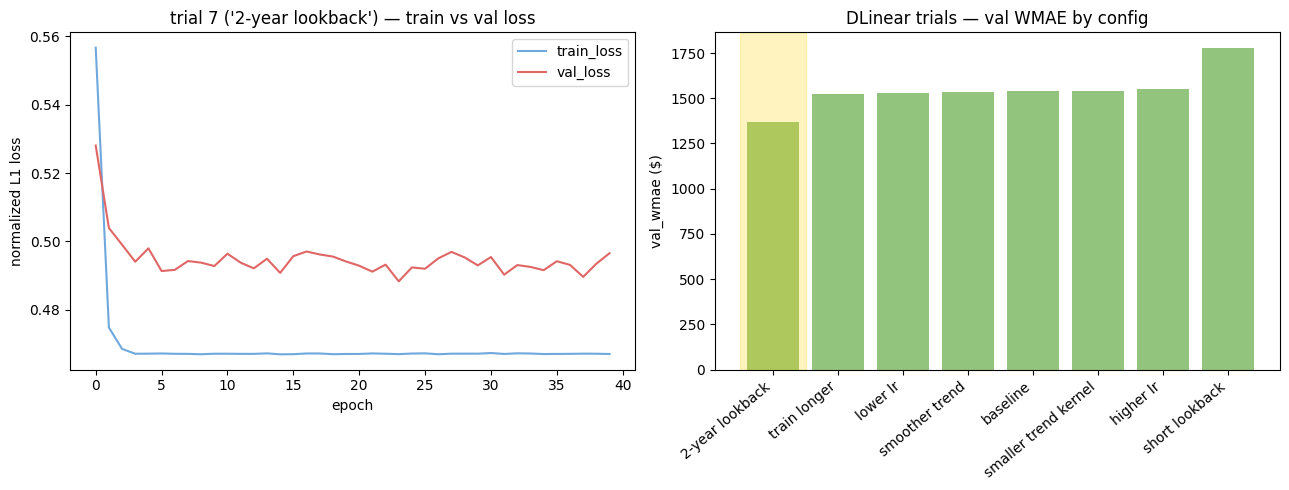

In [9]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(tracker._history[best_id])
summary = tracker.summary().sort_values("val_wmae").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss", color="#6fa8dc")
if "val_loss" in hist_df:
    ax.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss", color="#e06666")
ax.set_xlabel("epoch")
ax.set_ylabel("normalized L1 loss")
ax.set_title(f"trial {best_id} ('{tracker._notes.get(best_id, '')}') \u2014 train vs val loss")
ax.legend()

ax2 = axes[1]
x = np.arange(len(summary))
ax2.bar(x, summary["val_wmae"], color="#93c47d")
ax2.axvspan(-0.5, 0.5, color="gold", alpha=0.25)  # summary sorted asc -> index 0 = best
ax2.set_xticks(x)
ax2.set_xticklabels(summary["note"], rotation=40, ha="right")
ax2.set_ylabel("val_wmae ($)")
ax2.set_title("DLinear trials \u2014 val WMAE by config")

plt.tight_layout()
plt.savefig("/kaggle/working/dlinear_trainvsval.png", dpi=150)
plt.show()


## 6 · Kaggle submission (best config, final iteration only)

The comparison is on the 8-week holdout. The real test set is a **39-week**
future horizon, so a submission retrains the **best** config on **all** labelled
data with `pred_len = 39` and forecasts forward. Flip `RUN_SUBMISSION` on only
for the final run.

In [10]:
RUN_SUBMISSION = True
FINAL_CFG = TRIAL_CFGS[int(tracker.summary().iloc[0]["trial"])]
print("submission uses best cfg (trial %d):" % int(tracker.summary().iloc[0]["trial"]), FINAL_CFG)

if RUN_SUBMISSION:
    H = len(store.test_dates)
    set_seed(FINAL_CFG["seed"])
    Xf, Yf = store.make_full_windows(FINAL_CFG["input_len"], H)
    sub_model, _ = train_torch(build_model(FINAL_CFG, pred_len=H), Xf, Yf,
                            FINAL_CFG["lr"], FINAL_CFG["epochs"], FINAL_CFG["batch_size"])
    Xi, keys, mus, sds = store.make_forecast_inputs(FINAL_CFG["input_len"])
    sub_model.eval()
    with torch.no_grad():
        pf = sub_model(torch.tensor(Xi).to(DEVICE)).cpu().numpy()
    pbk = {k: pf[i] * sds[i] + mus[i] for i, k in enumerate(keys)}
    for k in store.series:
        pbk.setdefault(k, store.naive_submit(k))
    submission = C.build_submission(panel, store, pbk)
    submission.to_csv("submission.csv", index=False)
    print("wrote submission.csv:", submission.shape)
    display(submission.head())

    # ---- log the final iteration to MLflow (best cfg + submission + model) --
    best_row = tracker.summary().iloc[0]
    torch.save(sub_model.state_dict(), "/kaggle/working/dlinear_best.pt")
    tracker.log_artifacts_run(
        "dlinear_Best",
        params={**FINAL_CFG, "submission_horizon": H},
        metrics={m: float(best_row[m]) for m in
                 ["val_wmae", "val_mae", "val_rmse", "val_r2", "train_wmae", "train_mae"]
                 if m in best_row.index},
        artifacts=["submission.csv", "/kaggle/working/dlinear_best.pt",
                   "/kaggle/working/dlinear_experiments.csv"],
        texts={"model_summary.txt": str(build_model(FINAL_CFG, pred_len=H))})

submission uses best cfg (trial 7): {'input_len': 104, 'pred_len': 8, 'epochs': 40, 'lr': 0.001, 'batch_size': 512, 'seed': 42, 'kernel_size': 25}
wrote submission.csv: (115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,24412.6992
1,1_1_2012-11-09,26038.9824
2,1_1_2012-11-16,23703.0469
3,1_1_2012-11-23,29455.1680
4,1_1_2012-11-30,23681.6387


🏃 View run dlinear_Best at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/5/runs/05f023565cd8412abd5957c0618a8ce7
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/5
[dlinear] logged final artifacts run 'dlinear_Best'


### 6b · Actual vs Predicted (held-out val, best config)

Held-out `(y_true, y_pred)` pairs only exist inside `run_trial()` (during training) and
aren't kept after a trial finishes, so this re-fits **only the winning
`FINAL_CFG`** — one extra run, not a relog of the sweep (`tracker=None`, nothing
gets written to the tracker or MLflow). Same seed as the original trial, so
`val_wmae` below should reproduce the leaderboard number as a sanity check.

val_wmae (should match leaderboard): 1366.7


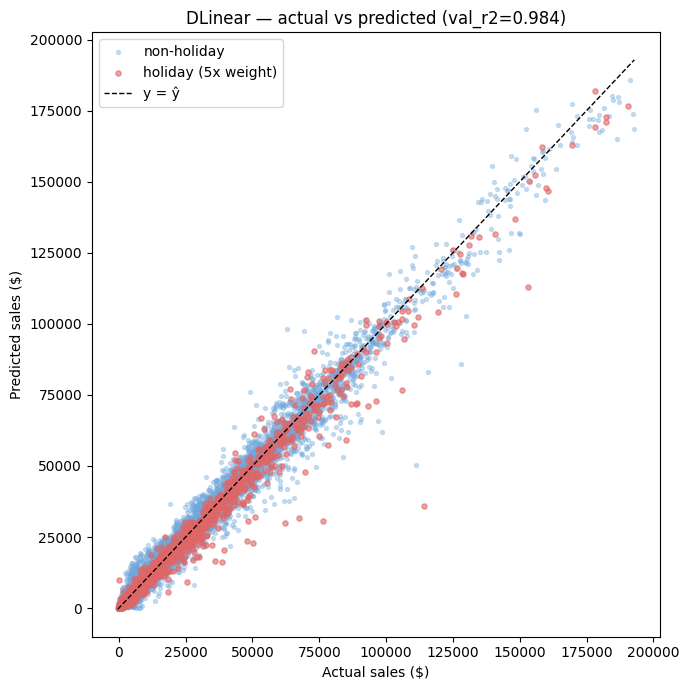

largest residual: 78317.51 -> row:


,Store,Dept,Date,IsHoliday,y_true,y_pred
6611,13,3,2012-09-07,1.0000,114230.6000,35913.0898


In [11]:
plot_metrics, plot_merged = run_trial(FINAL_CFG, tracker=None, note="best_for_plot",
                                      return_predictions=True)
print("val_wmae (should match leaderboard):", plot_metrics["val_wmae"])

fig, ax = plt.subplots(figsize=(7, 7))
is_hol = plot_merged["IsHoliday"].astype(bool)
ax.scatter(plot_merged.loc[~is_hol, "y_true"], plot_merged.loc[~is_hol, "y_pred"],
           s=8, alpha=0.35, color="#6fa8dc", label="non-holiday")
ax.scatter(plot_merged.loc[is_hol, "y_true"], plot_merged.loc[is_hol, "y_pred"],
           s=14, alpha=0.6, color="#e06666", label="holiday (5x weight)")

lo = min(plot_merged["y_true"].min(), plot_merged["y_pred"].min())
hi = max(plot_merged["y_true"].max(), plot_merged["y_pred"].max())
ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, linestyle="--", label="y = \u0177")

ax.set_xlabel("Actual sales ($)")
ax.set_ylabel("Predicted sales ($)")
ax.set_title(f"DLinear \u2014 actual vs predicted (val_r2={plot_metrics['val_r2']:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/dlinear_actualvspredicted.png", dpi=150)
plt.show()

resid = (plot_merged["y_pred"] - plot_merged["y_true"]).abs()
worst = plot_merged.loc[[resid.idxmax()]]
print("largest residual:", round(resid.max(), 2), "-> row:")
display(worst)
